# Modeling

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# Paths (same as your cleaning notebook)
BASE_DIR = "/content/drive/MyDrive/cs 163-capstone"
DATA_DIR = os.path.join(BASE_DIR, "data")

# Load clean dataset
clean_path = os.path.join(DATA_DIR, "final_clean.csv")
df_model = pd.read_csv(clean_path)

print("✅ Loaded dataset from:", clean_path)
print("Shape:", df_model.shape)

df_model.head()

Mounted at /content/drive
✅ Loaded dataset from: /content/drive/MyDrive/cs 163-capstone/data/final_clean.csv
Shape: (1427, 43)


,ZIP,Diesel,Electric,Flex_Fuel,Gasoline,Gasoline_Hybrid,Hydrogen,Natural_Gas,PHEV,Propane,Total_Cars,Total_EV,EV_perc,Median_Household_Income,Latino_perc,White_perc,Asian_perc,Black_perc,BachOrHigher_perc,Total_Population,Zillow_Home_Value_Index,Gini,RenterShare,SingleFamilyShare,MultiUnitShare,ZeroVehicleShare,PovertyShare,CES_Score_ZIP,PollutionBurden_ZIP,Traffic_ZIP,County,Num_Stations,Total_Ports,L2_Ports,DC_Fast_Ports,HomeownerShare,ChargersPer1000EV,Diesel_share,Gasoline_share,Gasoline_Hybrid_share,PHEV_share,Electric_share,PortsPer10kPeople
0,94027,89,723,137,4764,380,1,0,167,0,6261,891,14.23,250001.0,8.8,68.0,18.5,1.2,84.7,7213,7397088.91,0.5047,0.115487,1.000000,0.000000,0.009735,0.033789,4.965985,4.938998,584.975507,San Mateo,1.0,2.0,2.0,0.0,0.884513,1.122334,0.014215,0.760901,0.060693,0.026673,0.115477,2.772771
1,94022,228,1880,255,12682,1416,8,1,502,0,16972,2390,14.08,250001.0,5.2,53.7,36.2,0.2,87.6,20069,4383734.10,0.4986,0.197026,0.846250,0.152745,0.022305,0.030119,4.278299,4.142339,1103.700570,Santa Clara,17.0,153.0,133.0,20.0,0.802974,7.112971,0.013434,0.747231,0.083432,0.029578,0.110771,76.236982
2,94301,141,1229,163,8513,1141,5,5,352,0,11549,1586,13.73,184932.0,6.2,59.6,24.4,2.5,82.0,17243,3763337.05,0.5426,0.446466,0.584333,0.415667,0.099370,0.043670,7.792235,3.983527,563.050330,Santa Clara,15.0,65.0,64.0,1.0,0.553534,9.457755,0.012209,0.737120,0.098796,0.030479,0.106416,37.696457
3,94028,128,645,110,4451,609,1,1,188,0,6133,834,13.60,250001.0,9.0,79.5,5.9,0.0,85.2,6582,3708911.26,0.4921,0.133763,0.907373,0.092627,0.038276,0.032767,5.139967,4.151575,714.839738,San Mateo,2.0,4.0,4.0,0.0,0.866237,2.398082,0.020871,0.725746,0.099299,0.030654,0.105169,6.077180
4,94024,253,1981,246,14374,1649,12,3,571,0,19089,2564,13.43,250001.0,6.3,55.6,31.7,0.9,85.1,24203,3879869.05,0.4602,0.123569,0.972871,0.027129,0.012444,0.024339,6.942833,4.068953,822.684235,Santa Clara,2.0,30.0,26.0,4.0,0.876431,0.780031,0.013254,0.752999,0.086385,0.029913,0.103777,12.395158


## Model 1: EV Adoption Prediction

### Goal
This model aims to predict electric vehicle adoption rates (`EV_perc`) across California ZIP codes and identify the key factors that drive EV adoption.

### Why this model?
Exploratory data analysis showed that EV adoption is strongly associated with socioeconomic and housing-related factors such as income, education, and home values. This model formalizes those relationships and evaluates their predictive power using machine learning.

This serves as the **baseline model** for the project and helps answer:
> “Which community characteristics are most strongly associated with EV adoption?”

### Target Variable
- `EV_perc`: Percentage of vehicles that are electric in a ZIP code

### Features Used
- Median_Household_Income (economic capacity)
- BachOrHigher_perc (education level)
- Zillow_Home_Value_Index (wealth / housing cost)
- RenterShare (homeownership proxy)
- MultiUnitShare (housing structure)
- CES_Score_ZIP (environmental burden)
- PollutionBurden_ZIP
- Traffic_ZIP
- Total_Ports or PortsPer10kPeople (charging infrastructure)

### Models Used
We compare two models:

1. **Ridge Regression**
   - Handles multicollinearity between variables like income, education, and home value
   - Provides interpretable coefficients

2. **Random Forest Regressor**
   - Captures nonlinear relationships and interactions
   - Provides feature importance rankings

### What this model answers
- Which variables are the strongest predictors of EV adoption?
- Does infrastructure significantly influence adoption after controlling for socioeconomic factors?
- Are nonlinear relationships present in the data?

### Expected Insight
We expect socioeconomic variables (income, education, housing wealth) to be the strongest predictors of EV adoption, with infrastructure playing a secondary but supportive role.

In [2]:
# =========================
# Model 1: EV Adoption Prediction
# Ridge Regression + Random Forest Regressor
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# -------------------------
# 1. Create infrastructure feature if needed
# -------------------------

# Ports per 10,000 people is usually more stable than chargers per EV
if "PortsPer10kPeople" not in df_model.columns:
    df_model["PortsPer10kPeople"] = (
        df_model["Total_Ports"] / df_model["Total_Population"]
    ) * 10000

# Replace infinite values if population was 0 or missing
df_model = df_model.replace([np.inf, -np.inf], np.nan)

# -------------------------
# 2. Define target and features
# -------------------------

target = "EV_perc"

features = [
    "Median_Household_Income",
    "BachOrHigher_perc",
    "Zillow_Home_Value_Index",
    "RenterShare",
    "MultiUnitShare",
    "CES_Score_ZIP",
    "PollutionBurden_ZIP",
    "Traffic_ZIP",
    "PortsPer10kPeople"
]

model_data = df_model[features + [target]].dropna()

X = model_data[features]
y = model_data[target]

print("Modeling data shape:", model_data.shape)
print("Features used:", features)

# -------------------------
# 3. Train-test split
# -------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# 4. Ridge Regression
# -------------------------

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge)) # Fixed: Removed squared=False
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print("\nRidge Regression Results")
print("R²:", round(ridge_r2, 4))
print("RMSE:", round(ridge_rmse, 4))
print("MAE:", round(ridge_mae, 4))

# -------------------------
# 5. Random Forest Regressor
# -------------------------

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None,
    min_samples_leaf=3
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf)) # Fixed: Removed squared=False
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("\nRandom Forest Results")
print("R²:", round(rf_r2, 4))
print("RMSE:", round(rf_rmse, 4))
print("MAE:", round(rf_mae, 4))

# -------------------------
# 6. Compare model results
# -------------------------

results = pd.DataFrame({
    "Model": ["Ridge Regression", "Random Forest"],
    "R2": [ridge_r2, rf_r2],
    "RMSE": [ridge_rmse, rf_rmse],
    "MAE": [ridge_mae, rf_mae]
})

results

Modeling data shape: (1244, 10)
Features used: ['Median_Household_Income', 'BachOrHigher_perc', 'Zillow_Home_Value_Index', 'RenterShare', 'MultiUnitShare', 'CES_Score_ZIP', 'PollutionBurden_ZIP', 'Traffic_ZIP', 'PortsPer10kPeople']

Ridge Regression Results
R²: 0.8729
RMSE: 0.8661
MAE: 0.5964

Random Forest Results
R²: 0.8944
RMSE: 0.7896
MAE: 0.5027


,Model,R2,RMSE,MAE
0,Ridge Regression,0.872905,0.866134,0.596381
1,Random Forest,0.894376,0.789593,0.502661


In [3]:
# Random Forest feature importance
rf_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance_df

,Feature,Importance
1,BachOrHigher_perc,0.841160
2,Zillow_Home_Value_Index,0.062411
0,Median_Household_Income,0.044461
7,Traffic_ZIP,0.014862
6,PollutionBurden_ZIP,0.009239
3,RenterShare,0.007601
4,MultiUnitShare,0.007513
5,CES_Score_ZIP,0.006587
8,PortsPer10kPeople,0.006167


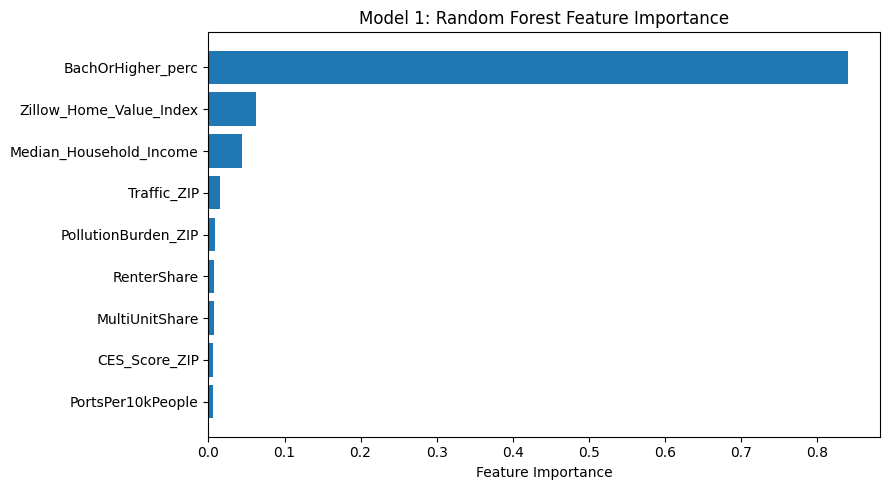

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.barh(rf_importance_df["Feature"], rf_importance_df["Importance"])
plt.xlabel("Feature Importance")
plt.title("Model 1: Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [5]:
# ridge coefficients

ridge_coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": ridge_model.named_steps["ridge"].coef_
}).sort_values(by="Coefficient", ascending=False)

ridge_coef_df

,Feature,Coefficient
1,BachOrHigher_perc,1.515519
2,Zillow_Home_Value_Index,0.805501
0,Median_Household_Income,0.556622
5,CES_Score_ZIP,0.426073
4,MultiUnitShare,0.152418
8,PortsPer10kPeople,0.133949
7,Traffic_ZIP,0.085817
6,PollutionBurden_ZIP,-0.094682
3,RenterShare,-0.156513


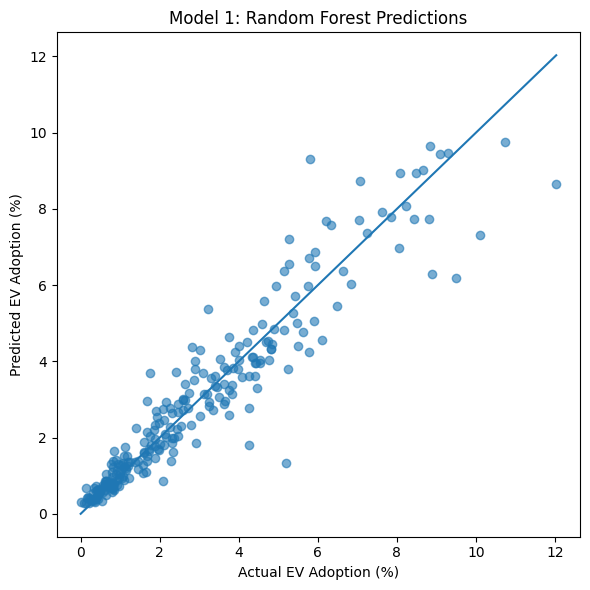

In [6]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6)

plt.xlabel("Actual EV Adoption (%)")
plt.ylabel("Predicted EV Adoption (%)")
plt.title("Model 1: Random Forest Predictions")

# Perfect prediction line
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.tight_layout()
plt.show()

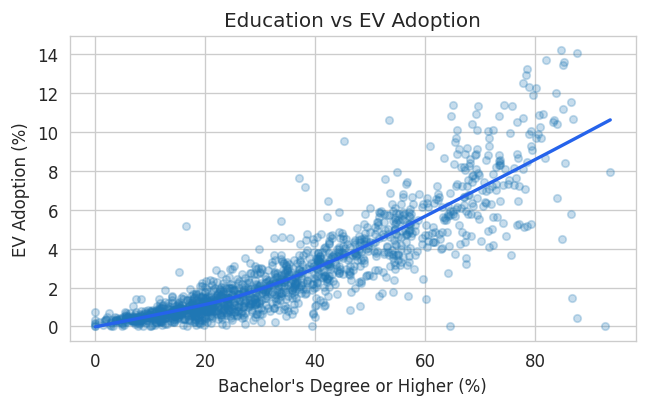

In [8]:
import seaborn as sns
plt.figure(figsize=(5.5,3.5), dpi=120)
sns.set_style("whitegrid")

sns.regplot(
    x="BachOrHigher_perc",
    y="EV_perc",
    data=df_model,
    lowess=True,
    scatter_kws={"alpha":0.25, "s":20},
    line_kws={"color":"#2563eb", "linewidth":2}
)

plt.title("Education vs EV Adoption")
plt.xlabel("Bachelor's Degree or Higher (%)")
plt.ylabel("EV Adoption (%)")

plt.tight_layout()

plt.savefig("education_vs_ev.png", dpi=300, bbox_inches="tight")  # ← ADD THIS
plt.show()

### Model 1 Results & Interpretation

Both Ridge Regression and Random Forest models achieve strong predictive performance (R² ≈ 0.87–0.89), indicating that EV adoption across California ZIP codes can be largely explained by observable socioeconomic, housing, environmental, and infrastructure factors.

#### Key Drivers of EV Adoption

The Random Forest feature importance results reveal that **educational attainment (BachOrHigher_perc)** is by far the most important predictor of EV adoption, accounting for over 84% of the model’s explanatory power. This suggests that communities with higher levels of education are significantly more likely to adopt electric vehicles.

Housing wealth and income also play important roles. The Zillow Home Value Index and Median Household Income are the next most influential features, indicating that **economic capacity and wealth strongly enable EV adoption**. These findings reinforce the idea that EV adoption is closely tied to broader socioeconomic advantage.

#### Secondary Factors

Environmental and infrastructure variables have noticeably smaller contributions. While traffic, pollution burden, and charging infrastructure (PortsPer10kPeople) show some influence, their importance is relatively limited compared to education and wealth. This suggests that **infrastructure alone is not the primary driver of EV adoption**, but rather a supporting factor.

#### Directional Insights (Ridge Regression)

The Ridge Regression coefficients provide insight into the direction of these relationships:

- Education, home value, and income all have strong positive coefficients, confirming that **higher socioeconomic status is associated with higher EV adoption**.
- RenterShare has a negative coefficient, suggesting that **areas with more renters (and likely less access to home charging) have lower EV adoption**.
- Pollution burden shows a slight negative relationship, indicating that **more environmentally burdened communities may have lower adoption rates**.

#### Overall Insight

Taken together, these results indicate that EV adoption is driven primarily by **structural socioeconomic factors**, particularly education and wealth. Charging infrastructure plays a secondary role and does not appear sufficient on its own to overcome underlying disparities. This highlights the importance of considering affordability, housing access, and broader socioeconomic conditions when evaluating equity in the transition to electric vehicles.

## Model 2: Interaction Model (Income × Infrastructure)

### Goal
This model investigates whether the effect of charging infrastructure on EV adoption varies across income levels.

### Why this model?
While Model 1 showed that infrastructure has a relatively small overall effect on EV adoption, it does not capture whether infrastructure matters more for certain communities than others.

In reality, infrastructure may:
- Have a stronger impact in lower-income areas (reducing barriers), or
- Primarily benefit higher-income areas (reinforcing inequality)

This model introduces an interaction term to test this relationship.

### Target Variable
- `EV_perc`: Percentage of vehicles that are electric

### Key Feature
- `Income × Infrastructure` interaction term

### Features Used
- Median_Household_Income
- PortsPer10kPeople
- Interaction: income * infrastructure
- BachOrHigher_perc
- Zillow_Home_Value_Index
- RenterShare
- MultiUnitShare
- CES_Score_ZIP
- PollutionBurden_ZIP
- Traffic_ZIP

### Models Used
- Ridge Regression (for interpretable coefficients)

### What this model answers
- Does infrastructure impact EV adoption differently across income levels?
- Does infrastructure reduce inequality or reinforce it?

### Expected Insight
If the interaction term is:
- **Positive** → infrastructure benefits high-income areas more (reinforces inequality)
- **Negative** → infrastructure benefits low-income areas more (reduces inequality)

In [9]:
# Create interaction term
df_model["Income_Infrastructure_Interaction"] = (
    df_model["Median_Household_Income"] * df_model["PortsPer10kPeople"]
)


features_interaction = [
    "Median_Household_Income",
    "PortsPer10kPeople",
    "Income_Infrastructure_Interaction",
    "BachOrHigher_perc",
    "Zillow_Home_Value_Index",
    "RenterShare",
    "MultiUnitShare",
    "CES_Score_ZIP",
    "PollutionBurden_ZIP",
    "Traffic_ZIP"
]

target = "EV_perc"

model_data = df_model[features_interaction + [target]].dropna()

X = model_data[features_interaction]
y = model_data[target]

print("Shape:", model_data.shape)

Shape: (1244, 11)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

ridge_model_interaction = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model_interaction.fit(X_train, y_train)

y_pred = ridge_model_interaction.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\nInteraction Model Results")
print("R²:", round(r2, 4))
print("RMSE:", round(rmse, 4))
print("MAE:", round(mae, 4))


Interaction Model Results
R²: 0.8723
RMSE: 0.8681
MAE: 0.5953


In [12]:
# extract coefficients:

coef_df = pd.DataFrame({
    "Feature": features_interaction,
    "Coefficient": ridge_model_interaction.named_steps["ridge"].coef_
}).sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
3,BachOrHigher_perc,1.522546
4,Zillow_Home_Value_Index,0.798209
0,Median_Household_Income,0.537475
7,CES_Score_ZIP,0.427971
6,MultiUnitShare,0.133319
2,Income_Infrastructure_Interaction,0.105808
9,Traffic_ZIP,0.087457
1,PortsPer10kPeople,0.048027
8,PollutionBurden_ZIP,-0.096603
5,RenterShare,-0.145710


<Figure size 1050x675 with 0 Axes>

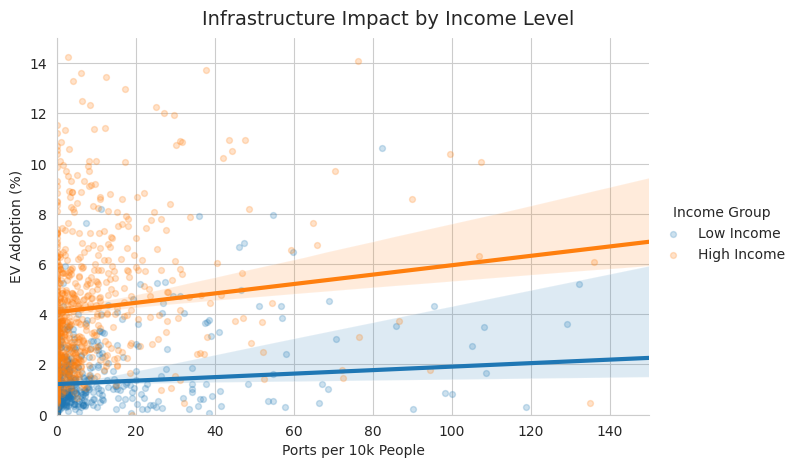

Saved image to: model2_infrastructure_income_interaction.png


In [13]:
# Model 2 Visual: Infrastructure Impact by Income Level

import seaborn as sns
import matplotlib.pyplot as plt
import os

# Create income groups: bottom 50% vs top 50%
df_model["income_group"] = pd.qcut(
    df_model["Median_Household_Income"],
    2,
    labels=["Low Income", "High Income"]
)

# Create figure
plt.figure(figsize=(7, 4.5), dpi=150)
sns.set_style("whitegrid")

plot = sns.lmplot(
    x="PortsPer10kPeople",
    y="EV_perc",
    hue="income_group",
    data=df_model,
    height=4.5,
    aspect=1.5,
    scatter_kws={"alpha": 0.22, "s": 18},
    line_kws={"linewidth": 3}
)

# Labels and title
plot.set_axis_labels("Ports per 10k People", "EV Adoption (%)")
plot.fig.suptitle("Infrastructure Impact by Income Level", y=1.03, fontsize=14)

# Zoom into the main range
plt.xlim(0, 150)
plt.ylim(0, 15)

# Clean legend title
plot._legend.set_title("Income Group")

# Save image
image_path = "model2_infrastructure_income_interaction.png"
plt.savefig(image_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved image to:", image_path)

### Model 2 Results & Interpretation: Interaction Effects

The interaction model achieves similar predictive performance to the baseline model (R² ≈ 0.87), indicating that adding the interaction term does not significantly change overall predictive accuracy but provides important insight into how different factors interact.

#### Key Finding: Infrastructure Effects Depend on Income

The interaction term between median household income and charging infrastructure (PortsPer10kPeople) has a **positive coefficient (0.106)**. This indicates that the impact of infrastructure on EV adoption is **stronger in higher-income areas**.

In other words, increasing charging infrastructure leads to larger increases in EV adoption in wealthier communities compared to lower-income ones.

#### Interpretation

This suggests that infrastructure alone does not equally benefit all communities. Instead, it appears to **amplify existing socioeconomic advantages**. Higher-income communities are better positioned to take advantage of new charging infrastructure due to factors such as affordability, access to vehicles, and readiness to adopt new technologies.

#### Supporting Patterns

- Education remains the strongest predictor of EV adoption, reinforcing the importance of structural socioeconomic factors.
- Infrastructure (PortsPer10kPeople) has a relatively small standalone effect, but its interaction with income reveals a more complex relationship.
- RenterShare continues to show a negative relationship, suggesting that access to private charging (e.g., home charging) remains a barrier.

#### Overall Insight

These results indicate that while infrastructure expansion is important, it may not be sufficient to reduce disparities in EV adoption. Without addressing underlying socioeconomic constraints, infrastructure investments may disproportionately benefit already advantaged communities.

This highlights the need for more targeted, equity-focused strategies to ensure that infrastructure expansion supports broader and more inclusive EV adoption.

## Model 3: EV Desert Classification

### Goal
This model identifies which ZIP codes are “EV deserts,” defined as areas with very low EV adoption. Instead of predicting EV adoption as a continuous variable, this model classifies whether a ZIP code is being left behind in the transition to electric vehicles.

### Why this model?
While previous models showed that EV adoption is driven by socioeconomic factors and that infrastructure benefits are uneven, they do not explicitly identify which communities are most underserved.

This model reframes the problem as a classification task to answer:
> “Which communities are most at risk of being left behind in EV adoption?”

### Target Variable
- `EV_desert`: Binary variable
  - 1 → ZIP code is in the bottom 20% of EV adoption
  - 0 → otherwise

### Features Used
- Median_Household_Income
- BachOrHigher_perc
- Zillow_Home_Value_Index
- RenterShare
- MultiUnitShare
- CES_Score_ZIP
- PollutionBurden_ZIP
- Traffic_ZIP
- PortsPer10kPeople

### Models Used
We compare two models:

1. **Logistic Regression**
   - Interpretable coefficients (odds of being an EV desert)

2. **Random Forest Classifier**
   - Captures nonlinear relationships
   - Provides feature importance

### What this model answers
- Which factors most strongly predict whether a community is left behind?
- Are EV deserts primarily driven by socioeconomic disadvantage?
- Does infrastructure reduce the likelihood of being an EV desert?

### Expected Insight
We expect EV deserts to be concentrated in lower-income, lower-education, higher-renter, and higher-burden communities, with infrastructure playing a secondary role.

In [14]:
# Define EV desert threshold (bottom 20%)
threshold = df_model["EV_perc"].quantile(0.2)

df_model["EV_desert"] = (df_model["EV_perc"] <= threshold).astype(int)

print("EV desert threshold:", threshold)
print(df_model["EV_desert"].value_counts())

EV desert threshold: 0.6619999999999999
EV_desert
0    1141
1     286
Name: count, dtype: int64


In [15]:
features_class = [
    "Median_Household_Income",
    "BachOrHigher_perc",
    "Zillow_Home_Value_Index",
    "RenterShare",
    "MultiUnitShare",
    "CES_Score_ZIP",
    "PollutionBurden_ZIP",
    "Traffic_ZIP",
    "PortsPer10kPeople"
]

target = "EV_desert"

model_data = df_model[features_class + [target]].dropna()

X = model_data[features_class]
y = model_data[target]

print("Shape:", model_data.shape)

Shape: (1244, 10)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("\nLogistic Regression Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Logistic Regression Results
Accuracy: 0.9237
ROC AUC: 0.968

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95       208
           1       0.78      0.76      0.77        41

    accuracy                           0.92       249
   macro avg       0.86      0.86      0.86       249
weighted avg       0.92      0.92      0.92       249



In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=3
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

print("\nRandom Forest Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Results
Accuracy: 0.9478
ROC AUC: 0.9736

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       208
           1       0.82      0.88      0.85        41

    accuracy                           0.95       249
   macro avg       0.90      0.92      0.91       249
weighted avg       0.95      0.95      0.95       249



In [19]:
rf_importance_df = pd.DataFrame({
    "Feature": features_class,
    "Importance": rf_clf.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance_df

,Feature,Importance
1,BachOrHigher_perc,0.379592
2,Zillow_Home_Value_Index,0.257562
0,Median_Household_Income,0.139336
7,Traffic_ZIP,0.072769
5,CES_Score_ZIP,0.038927
4,MultiUnitShare,0.037157
3,RenterShare,0.028113
6,PollutionBurden_ZIP,0.025986
8,PortsPer10kPeople,0.020558


/tmp/ipykernel_5035/3870796197.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


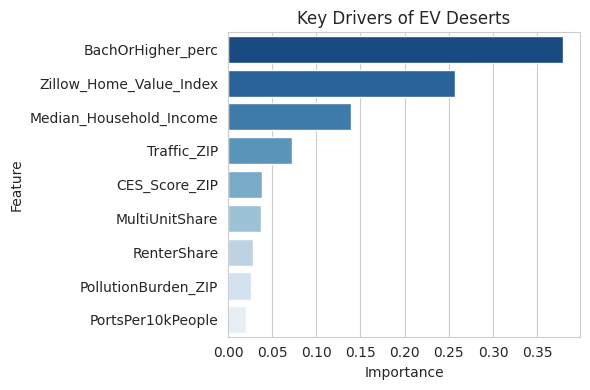

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.set_style("whitegrid")

sns.barplot(
    x=rf_importance_df["Importance"],
    y=rf_importance_df["Feature"],
    palette="Blues_r"
)

plt.title("Key Drivers of EV Deserts", fontsize=12)
plt.xlabel("Importance", fontsize=10)
plt.ylabel("Feature", fontsize=10)

plt.tight_layout()

plt.savefig("model3_ev_desert_importance.png", dpi=300, bbox_inches="tight")
plt.show()

### Model 3 Results & Interpretation: EV Desert Classification

Both models perform extremely well in identifying EV deserts, with Logistic Regression achieving a ROC AUC of 0.968 and Random Forest reaching 0.974. This indicates that EV deserts can be predicted with high accuracy using observable community characteristics.

#### Key Drivers of EV Deserts

The Random Forest feature importance results show that **educational attainment (BachOrHigher_perc)** is the strongest predictor of whether a ZIP code is an EV desert, followed by housing wealth (Zillow Home Value Index) and median household income.

This indicates that EV deserts are primarily concentrated in communities with:
- Lower levels of education
- Lower home values
- Lower income

These results reinforce the findings from Model 1, showing that **the same socioeconomic factors that drive EV adoption also determine which communities are left behind**.

#### Secondary Factors

Environmental and housing variables play a smaller but still meaningful role:
- Traffic and CES score contribute moderately, suggesting that environmental burden and urban conditions are associated with EV desert likelihood.
- RenterShare has a smaller impact, but still aligns with the idea that lack of home charging access may limit adoption.

Charging infrastructure (PortsPer10kPeople) has relatively low importance, indicating that **infrastructure alone is not sufficient to prevent a community from becoming an EV desert**.

#### Model Performance Insights

The classification report shows:
- High precision and recall for non-desert ZIP codes
- Strong but slightly lower recall for EV deserts (≈ 0.76–0.88), meaning some underserved areas are harder to detect

This reflects the real-world complexity of identifying disadvantaged communities, where multiple interacting factors influence outcomes.

#### Overall Insight

EV deserts are not random—they are systematically concentrated in communities with lower socioeconomic advantage. While infrastructure plays a role, it does not appear to be the primary factor determining whether a community is left behind.

These findings suggest that **addressing EV adoption inequality requires more than expanding charging infrastructure—it requires tackling underlying socioeconomic barriers such as affordability, housing access, and education**.

### Observations on Charging Infrastructure

Initial modeling attempts revealed that charging infrastructure (PortsPer10kPeople) was difficult to predict using socioeconomic and EV adoption variables. Even after applying transformations, regression models showed weak performance, suggesting that infrastructure availability is not strongly determined by these factors alone.

Further inspection of the data revealed additional complexity. Charging infrastructure is recorded at specific point locations and assigned to ZIP codes based on station addresses, while EV adoption data is aggregated at the ZIP code level. This introduces spatial mismatch, where some ZIP codes may appear to have little or no infrastructure despite nearby access.

Given these limitations, we shift from purely predictive modeling to a more descriptive and comparative analysis of infrastructure distribution. This allows us to better evaluate whether infrastructure is equitably distributed across communities.

## Model 4: Infrastructure Desert Classification

### Goal
This model identifies communities with little or no access to EV charging infrastructure.

### Why this model?
Directly predicting infrastructure levels proved difficult due to spatial mismatch and the influence of external factors such as policy and investment decisions.

To address this, we reframe the problem as a classification task, identifying “infrastructure deserts” rather than predicting exact infrastructure levels.

### Target Variable
- `infra_desert`
  - 1 → ZIP code has little or no infrastructure
  - 0 → otherwise

### Features Used
- EV_perc (controls for demand)
- Median_Household_Income
- BachOrHigher_perc
- Zillow_Home_Value_Index
- RenterShare
- MultiUnitShare
- CES_Score_ZIP
- PollutionBurden_ZIP
- Traffic_ZIP

### Models Used
- Logistic Regression
- Random Forest Classifier

### What this model answers
- Which communities lack infrastructure?
- Is infrastructure access aligned with demand?
- Are disadvantaged communities more likely to lack infrastructure?

### Expected Insight
If infrastructure is equitable:
- EV adoption should strongly predict access

If inequitable:
- socioeconomic variables will dominate

In [21]:
# Define threshold EXCLUDING zeros
nonzero = df_model[df_model["PortsPer10kPeople"] > 0]

threshold = nonzero["PortsPer10kPeople"].quantile(0.2)

# Create label: zero OR low infrastructure
df_model["infra_desert"] = (
    (df_model["PortsPer10kPeople"] == 0) |
    (df_model["PortsPer10kPeople"] <= threshold)
).astype(int)

print("Threshold (nonzero):", threshold)
print(df_model["infra_desert"].value_counts())

Threshold (nonzero): 1.5345669684666028
infra_desert
0    763
1    664
Name: count, dtype: int64


In [22]:
features_infra_class = [
    "EV_perc",
    "Median_Household_Income",
    "BachOrHigher_perc",
    "Zillow_Home_Value_Index",
    "RenterShare",
    "MultiUnitShare",
    "CES_Score_ZIP",
    "PollutionBurden_ZIP",
    "Traffic_ZIP"
]

target = "infra_desert"

model_data = df_model[features_infra_class + [target]].dropna()

X = model_data[features_infra_class]
y = model_data[target]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("Logistic ROC AUC:", roc_auc_score(y_test, y_prob))

Logistic ROC AUC: 0.7140583554376658


In [25]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=3
)

rf_model.fit(X_train, y_train)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("RF ROC AUC:", roc_auc_score(y_test, y_prob_rf))

RF ROC AUC: 0.691710875331565


In [26]:
rf_importance_df = pd.DataFrame({
    "Feature": features_infra_class,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance_df

,Feature,Importance
2,BachOrHigher_perc,0.150383
5,MultiUnitShare,0.138246
8,Traffic_ZIP,0.113756
3,Zillow_Home_Value_Index,0.113290
0,EV_perc,0.110115
4,RenterShare,0.107824
1,Median_Household_Income,0.092399
7,PollutionBurden_ZIP,0.087056
6,CES_Score_ZIP,0.086931


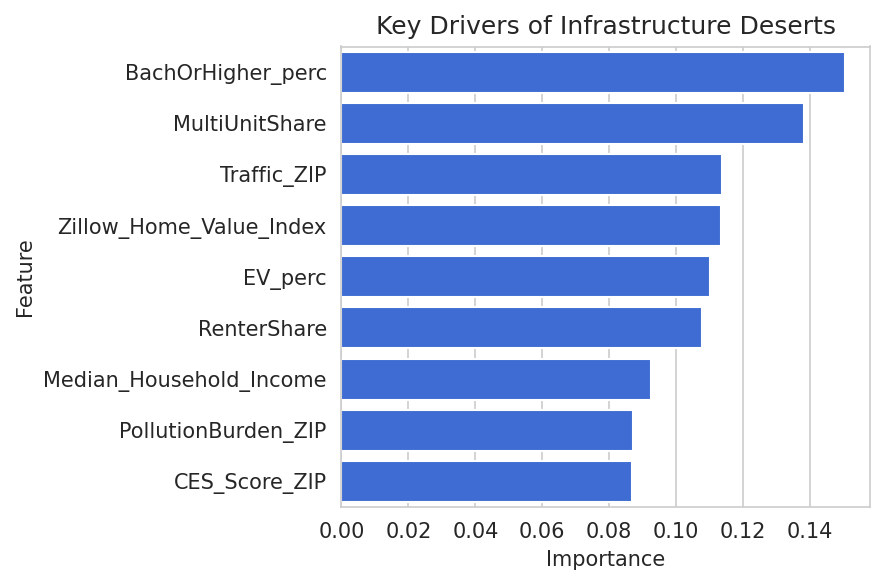

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use the feature importance dataframe from Model 4
# If needed, recreate it:
infra_importance_df = pd.DataFrame({
    "Feature": features_infra_class,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(6, 4), dpi=150)
sns.set_style("whitegrid")

sns.barplot(
    x="Importance",
    y="Feature",
    data=infra_importance_df.head(9),
    color="#2563eb"
)

plt.title("Key Drivers of Infrastructure Deserts", fontsize=12)
plt.xlabel("Importance", fontsize=10)
plt.ylabel("Feature", fontsize=10)

plt.tight_layout()
plt.savefig("model4_infra_desert_importance.png", dpi=300, bbox_inches="tight")
plt.show()

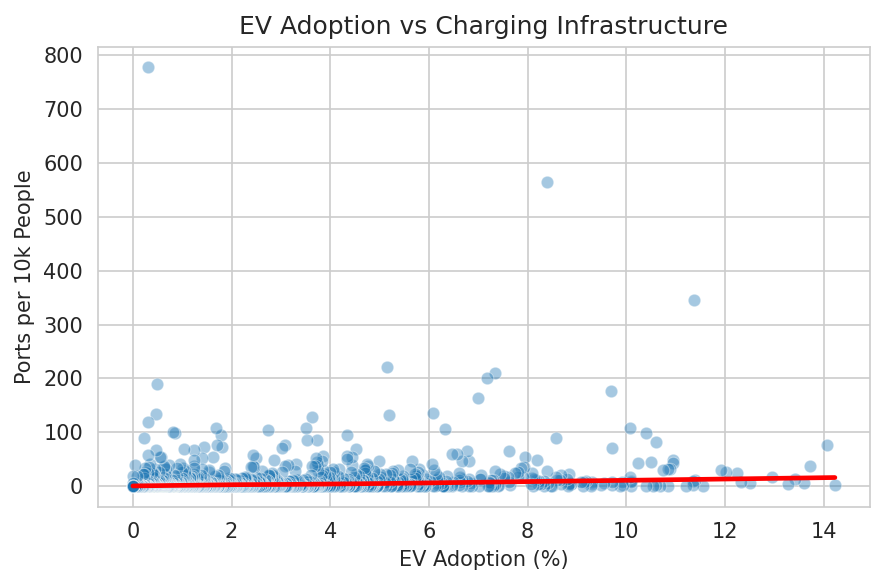

In [28]:
plt.figure(figsize=(6,4), dpi=150)
sns.set_style("whitegrid")

sns.scatterplot(
    x="EV_perc",
    y="PortsPer10kPeople",
    data=df_model,
    alpha=0.4
)

sns.regplot(
    x="EV_perc",
    y="PortsPer10kPeople",
    data=df_model,
    scatter=False,
    lowess=True,
    color="red"
)

plt.title("EV Adoption vs Charging Infrastructure")
plt.xlabel("EV Adoption (%)")
plt.ylabel("Ports per 10k People")

plt.tight_layout()
plt.savefig("model4_ev_vs_infra.png", dpi=300, bbox_inches="tight")
plt.show()

### Model 4 Results & Interpretation: Infrastructure Desert Classification

The infrastructure desert model achieves moderate predictive performance (ROC AUC ≈ 0.69–0.71), indicating that infrastructure availability can be partially explained by community characteristics, but is significantly less structured than EV adoption.

#### Key Finding: Infrastructure Is Not Strongly Aligned with Demand

EV adoption (EV_perc), which represents local demand for charging infrastructure, is not the dominant predictor in the model. Instead, variables such as educational attainment, housing structure, and urban characteristics (traffic) play a larger role.

This suggests that infrastructure placement is **not primarily driven by EV demand**, but is influenced by a broader set of socioeconomic and environmental factors.

#### Interpretation

If infrastructure were equitably distributed, EV adoption would be the strongest predictor of infrastructure access. However, the relatively low importance of EV_perc indicates that communities with similar levels of EV adoption may still have very different levels of infrastructure access.

Additionally, the moderate model performance suggests that infrastructure deployment is influenced by factors not captured in the dataset, such as policy decisions, funding programs, and private investment.

#### Overall Insight

Compared to EV adoption, which follows clear and predictable socioeconomic patterns, infrastructure availability is more uneven and less systematically distributed. This highlights a key imbalance in the EV transition:

- EV adoption is driven by structural socioeconomic factors
- Infrastructure access is less predictable and not consistently aligned with demand

Together, these findings suggest that current infrastructure deployment may not fully address disparities in access, reinforcing the need for more targeted and equitable planning strategies.

## Model 5: Adoption Pathway Model (Hybrid → EV Transition)

### Goal
This model explores whether hybrid vehicles serve as a stepping stone toward EV adoption.

### Why this model?
Previous models explain who adopts EVs, but not how adoption evolves. Hybrid and plug-in hybrid vehicles may represent intermediate steps toward full EV adoption.

This model tests:
> “Do communities with higher hybrid adoption also have higher EV adoption?”

### Target Variable
- EV_perc

### Key Features
- Gasoline_Hybrid_share (early transition)
- PHEV_share (late transition)

### Features Used
- Gasoline_Hybrid_share
- PHEV_share
- Median_Household_Income
- BachOrHigher_perc
- Zillow_Home_Value_Index
- RenterShare
- MultiUnitShare
- CES_Score_ZIP
- PollutionBurden_ZIP
- Traffic_ZIP
- PortsPer10kPeople

### What this model answers
- Do hybrids act as a stepping stone to EVs?
- Is PHEV more strongly associated with EV adoption than regular hybrids?
- Does this relationship persist after controlling for socioeconomic factors?

In [29]:
features_pathway = [
    "Gasoline_Hybrid_share",
    "PHEV_share",
    "Median_Household_Income",
    "BachOrHigher_perc",
    "Zillow_Home_Value_Index",
    "RenterShare",
    "MultiUnitShare",
    "CES_Score_ZIP",
    "PollutionBurden_ZIP",
    "Traffic_ZIP",
    "PortsPer10kPeople"
]

target = "EV_perc"

model_data = df_model[features_pathway + [target]].dropna()

X = model_data[features_pathway]
y = model_data[target]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred = ridge_model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))

R²: 0.9430339162056198


In [32]:
coef_df = pd.DataFrame({
    "Feature": features_pathway,
    "Coefficient": ridge_model.named_steps["ridge"].coef_
}).sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
1,PHEV_share,1.838617
4,Zillow_Home_Value_Index,0.630533
2,Median_Household_Income,0.371857
3,BachOrHigher_perc,0.313234
7,CES_Score_ZIP,0.241072
6,MultiUnitShare,0.163222
10,PortsPer10kPeople,0.085383
9,Traffic_ZIP,0.000363
5,RenterShare,-0.023242
8,PollutionBurden_ZIP,-0.163328


In [33]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=3
)

rf_model.fit(X_train, y_train)

importances = pd.DataFrame({
    "Feature": features_pathway,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importances

,Feature,Importance
1,PHEV_share,0.913291
4,Zillow_Home_Value_Index,0.031833
3,BachOrHigher_perc,0.020584
2,Median_Household_Income,0.019459
9,Traffic_ZIP,0.003208
10,PortsPer10kPeople,0.002726
0,Gasoline_Hybrid_share,0.002566
8,PollutionBurden_ZIP,0.001807
6,MultiUnitShare,0.001699
5,RenterShare,0.001656


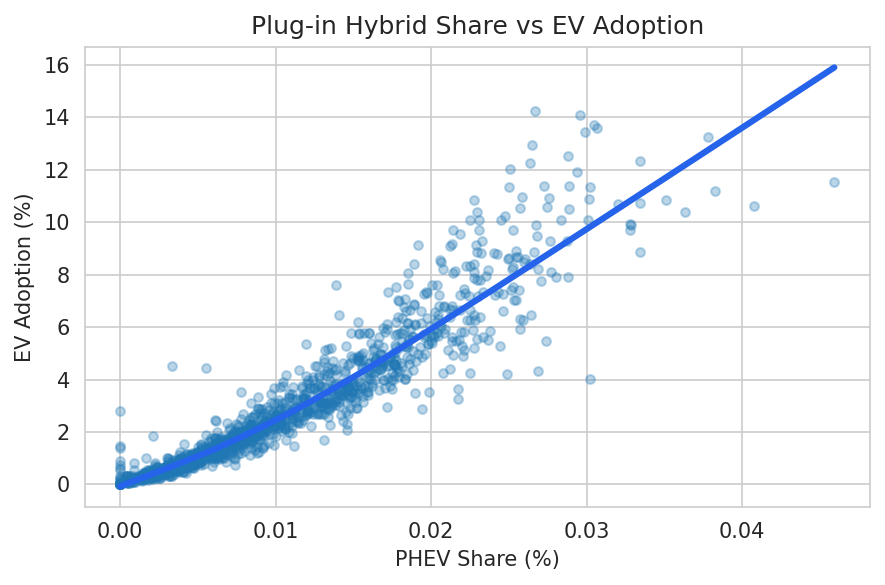

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4), dpi=150)
sns.set_style("whitegrid")

sns.regplot(
    x="PHEV_share",
    y="EV_perc",
    data=df_model,
    lowess=True,
    scatter_kws={"alpha": 0.3, "s": 18},
    line_kws={"color": "#2563eb", "linewidth": 3}
)

plt.title("Plug-in Hybrid Share vs EV Adoption")
plt.xlabel("PHEV Share (%)")
plt.ylabel("EV Adoption (%)")

plt.tight_layout()
plt.savefig("model5_phev_vs_ev.png", dpi=300, bbox_inches="tight")
plt.show()

### Model 5 Results & Interpretation: Adoption Pathway

The adoption pathway model achieves very high predictive performance (R² ≈ 0.94), largely driven by the strong relationship between plug-in hybrid vehicle (PHEV) adoption and EV adoption.

#### Key Finding: PHEVs Are Strongly Associated with EV Adoption

PHEV_share emerges as the dominant predictor of EV adoption, with both the largest coefficient and overwhelming importance in the Random Forest model. This indicates that communities with higher levels of PHEV adoption also tend to have significantly higher EV adoption.

Rather than implying causation, this suggests that PHEV adoption is a strong indicator of community readiness for electric vehicle technologies, reflecting underlying factors such as income, infrastructure access, and consumer preferences.

#### Divergence Between Hybrid Types

Interestingly, Gasoline_Hybrid_share shows a negative relationship with EV adoption after controlling for other factors. This suggests that traditional hybrid vehicles do not function as a stepping stone toward EV adoption in the same way as plug-in hybrids.

#### Interpretation

These findings highlight that the transition to EVs is not uniform across hybrid technologies:

- Plug-in hybrids appear to align closely with EV adoption, representing a later-stage transition toward full electrification.
- Traditional gasoline hybrids may reflect earlier or alternative adoption pathways that do not necessarily lead to EV uptake.

#### Overall Insight

EV adoption appears to follow a differentiated pathway, where only certain intermediate technologies (such as PHEVs) are associated with higher levels of EV adoption. This suggests that policies and incentives targeting plug-in technologies may be more effective in accelerating the transition to fully electric vehicles than those focused on traditional hybrids.

In [ ]:
# within high income below

In [35]:
df_model.columns

Index(['ZIP', 'Diesel', 'Electric', 'Flex_Fuel', 'Gasoline', 'Gasoline_Hybrid', 'Hydrogen', 'Natural_Gas', 'PHEV', 'Propane', 'Total_Cars',
       'Total_EV', 'EV_perc', 'Median_Household_Income', 'Latino_perc', 'White_perc', 'Asian_perc', 'Black_perc', 'BachOrHigher_perc',
       'Total_Population', 'Zillow_Home_Value_Index', 'Gini', 'RenterShare', 'SingleFamilyShare', 'MultiUnitShare', 'ZeroVehicleShare',
       'PovertyShare', 'CES_Score_ZIP', 'PollutionBurden_ZIP', 'Traffic_ZIP', 'County', 'Num_Stations', 'Total_Ports', 'L2_Ports',
       'DC_Fast_Ports', 'HomeownerShare', 'ChargersPer1000EV', 'Diesel_share', 'Gasoline_share', 'Gasoline_Hybrid_share', 'PHEV_share',
       'Electric_share', 'PortsPer10kPeople', 'Income_Infrastructure_Interaction', 'income_group', 'EV_desert', 'infra_desert'],
      dtype='object')

In [37]:
# Filter top income quintile
high_income_df = df_model[df_model["income_group"] == "High Income"]

features_hi = [
    "PortsPer10kPeople",
    "MultiUnitShare",
    "CES_Score_ZIP",
    "Traffic_ZIP",
    "PHEV_share",
    "BachOrHigher_perc"
]

target = "EV_perc"

model_data = high_income_df[features_hi + [target]].dropna()

X = model_data[features_hi]
y = model_data[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Ridge
model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))

# Coefficients
coef_df = pd.DataFrame({
    "Feature": features_hi,
    "Coefficient": model.named_steps["ridge"].coef_
}).sort_values(by="Coefficient", ascending=False)

coef_df

R²: 0.8949595588706404


,Feature,Coefficient
4,PHEV_share,1.775992
5,BachOrHigher_perc,0.849175
0,PortsPer10kPeople,0.261236
3,Traffic_ZIP,0.108706
2,CES_Score_ZIP,0.024095
1,MultiUnitShare,-0.227546


### High-Income Subset Analysis

To further investigate variation among advantaged communities, we restricted the analysis to ZIP codes in the top income quintile.

Within these high-income areas, EV adoption continues to vary significantly, indicating that income alone does not fully explain adoption patterns.

#### Key Findings

PHEV_share remains the strongest predictor of EV adoption, suggesting that communities with higher adoption of plug-in hybrid vehicles are more prepared for full EV adoption. This reinforces the idea that EV adoption follows a behavioral and technological readiness pathway.

Educational attainment also plays a major role, with higher levels of education associated with greater EV adoption even among wealthy communities.

Importantly, charging infrastructure (PortsPer10kPeople) becomes more relevant within this subset, indicating that once affordability constraints are removed, infrastructure availability begins to influence adoption.

Housing structure also matters, with higher proportions of multi-unit housing negatively associated with EV adoption, likely due to limited access to home charging.

#### Overall Insight

These results show that even among high-income communities, EV adoption is shaped by a combination of behavioral readiness, education, infrastructure access, and housing constraints.

This highlights that addressing EV adoption disparities requires more than increasing income levels—it also requires improving infrastructure access and reducing structural barriers to adoption.